# Bayesian Techniques for GNSS-R

 **GLITTER Training School Workshop**

 University of Luxembourg, 15 April 2026

 Will Handley (University of Cambridge / PolyChord Ltd)

 Workshop materials: [github.com/handley-lab/workshop-glitter](https://github.com/handley-lab/workshop-glitter)

## Installation

 **Important**: This workshop uses the `handley-lab` fork of BlackJAX, not the upstream BlackJAX package.
 You must install from the correct tag:

In [1]:
!pip install "blackjax @ git+https://github.com/handley-lab/blackjax.git"

!pip install jaxsgp4 anesthetic fgivenx tqdm matplotlib

  Cloning https://github.com/handley-lab/blackjax.git to ./pip-install-qnppvi16/blackjax_47267eb6c821434189ea97ca433aa216
  Running command git clone --filter=blob:none --quiet https://github.com/handley-lab/blackjax.git /tmp/pip-install-qnppvi16/blackjax_47267eb6c821434189ea97ca433aa216


  Resolved https://github.com/handley-lab/blackjax.git to commit ef45acd2f2fa0cca15adbdcd3ff7cb3a98987cb5


  Installing build dependencies ... -

 \

 done


...

 done


  Preparing metadata (pyproject.toml) ... -

 done



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Part 1: Bayesian Inference via Line Fitting

 We start with the simplest possible inverse problem: fitting a line to data.
 This is the same problem you solve with least squares, but we'll see how
 Bayesian inference gives you much more.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import blackjax
import tqdm
from anesthetic import NestedSamples

jax.config.update("jax_enable_x64", True)

### 1.1 Generate some noisy data

 True model: $y = 1 + x^3$ with non-uniform Gaussian noise.

In [3]:
np.random.seed(0)
n_data = 100
x = np.random.uniform(0, 1, n_data)
sigma = np.random.uniform(0.1, 0.5, n_data)
y_true = 1 + x**3
y = np.random.normal(y_true, sigma)

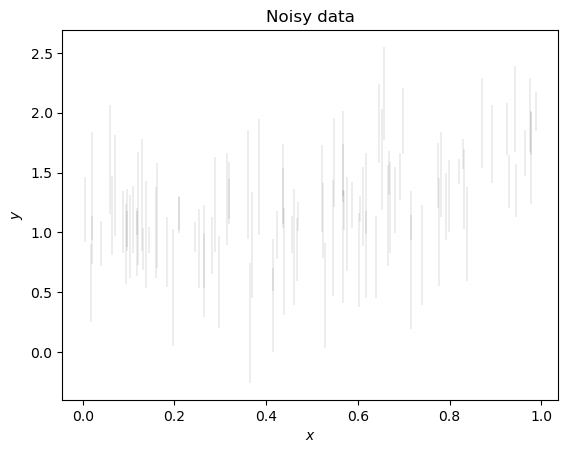

In [4]:
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr=sigma, fmt='.', color='k', capthick=0.1, markersize=0, linewidth=0.1)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Noisy data');

### 1.2 The $\chi^2$ approach

 You already know how to fit parameters to this data. For a model $y = f(x; \theta)$,
 minimise:
 $$\chi^2(\theta) = \sum_i \frac{|y_i - f(x_i;\theta)|^2}{\sigma_i^2}$$

 But this only gives you a **point estimate** — the "best fit". No error bars,
 no way to compare models, and no way to know if the fit is any good.

### 1.3 From $\chi^2$ to likelihood

 If the errors are Gaussian, then $\chi^2$ minimisation is equivalent to
 **maximum likelihood**:
 $$P(D|\theta) \propto e^{-\chi^2(\theta)/2}$$

 This is your **likelihood function** — the probability of observing the data
 given specific parameter values. Now we can do proper Bayesian inference.

### 1.4 Why sampling?

 Why not just evaluate the posterior on a grid? In 2D with 100 grid points
 per dimension, that's $100^2 = 10{,}000$ evaluations. In 15D (like the
 gravitational wave problem from the talk), it's $100^{15} = 10^{30}$.
 Grids are hopeless in high dimensions.

 **Samples** solve this. If you can generate $N$ representative draws
 $\theta_i \sim P(\theta|D)$, then:

 - **Error bars**: just compute the spread of $\theta_i$
 - **Propagation**: want to know how $f(\theta)$ is distributed?
   Just compute $f(\theta_i)$ for each sample. Sampling turns uncertainty
   quantification into repeated forward models.
 - **Marginals for free**: want $P(\theta_1)$ ignoring all other parameters?
   Just ignore the other columns.
 - **The golden rule**: stay in samples until the last moment, because
   $f(\langle \theta \rangle) \ne \langle f(\theta) \rangle$.

### 1.5 Set up the Bayesian problem

 We'll fit polynomials of different orders to the data.
 For a polynomial $y = a + bx$, we have parameters $\theta = (a, b)$.

 We need:
 - **Likelihood**: $P(D|\theta) \propto e^{-\chi^2/2}$
 - **Prior**: uniform over a reasonable range
 - **Nested sampling** will give us the **posterior** $P(\theta|D)$ and **evidence** $\mathcal{Z}$

In [5]:
x_jax = jnp.array(x)
y_jax = jnp.array(y)
sigma_jax = jnp.array(sigma)

def run_line_fitting(active_powers, num_live=500, rng_seed=42):
    """Run nested sampling for a polynomial model.

    active_powers: list of ints, e.g. [0, 1] for y = a + bx
    """
    param_names = [f"c{p}" for p in active_powers]
    num_dims = len(param_names)

    prior_min, prior_width = -3.0, 6.0

    def logprior_fn(params):
        lp = 0.0
        for name in param_names:
            lp = lp + jax.scipy.stats.uniform.logpdf(params[name], prior_min, prior_width)
        return lp

    def loglikelihood_fn(params):
        y_model = sum(params[f"c{p}"] * x_jax**p for p in active_powers)
        return jnp.sum(jax.scipy.stats.norm.logpdf(y_jax, y_model, sigma_jax))

    algo = blackjax.nss(
        logprior_fn=logprior_fn,
        loglikelihood_fn=loglikelihood_fn,
        num_delete=num_live // 10,
        num_inner_steps=num_dims * 5,
    )

    rng_key = jax.random.PRNGKey(rng_seed)
    rng_key, *prior_keys = jax.random.split(rng_key, num_dims + 1)
    particles = {
        name: jax.random.uniform(key, (num_live,), minval=prior_min, maxval=prior_min + prior_width)
        for name, key in zip(param_names, prior_keys)
    }

    live = jax.jit(algo.init)(particles)
    step_fn = jax.jit(algo.step)

    dead = []
    with tqdm.tqdm(desc=f"NS {active_powers}", unit=" dead") as pbar:
        while not live.integrator.logZ_live - live.integrator.logZ < -3:
            rng_key, subkey = jax.random.split(rng_key)
            live, dead_info = step_fn(subkey, live)
            dead.append(dead_info)
            pbar.update(num_live // 10)

    dead = blackjax.ns.utils.finalise(live, dead)

    labels = {name: f"${name}$" for name in param_names}
    samples = NestedSamples(
        dead.particles.position,
        logL=dead.particles.loglikelihood,
        logL_birth=dead.particles.loglikelihood_birth,
        labels=labels,
    )
    return samples

### 1.5 Run nested sampling for a linear model

 Model: $y = a + bx$ (powers 0 and 1)

In [6]:
samples_linear = run_line_fitting([0, 1])

NS [0, 1]: 0 dead [00:00, ? dead/s]

NS [0, 1]: 50 dead [00:01, 31.90 dead/s]

NS [0, 1]: 3000 dead [00:01, 2493.68 dead/s]

NS [0, 1]: 5300 dead [00:01, 3031.17 dead/s]

### 1.6 Parameter space: the posterior

 The posterior $P(\theta|D)$ lives in **parameter space** — the space of
 model coefficients. This is what nested sampling directly gives us.

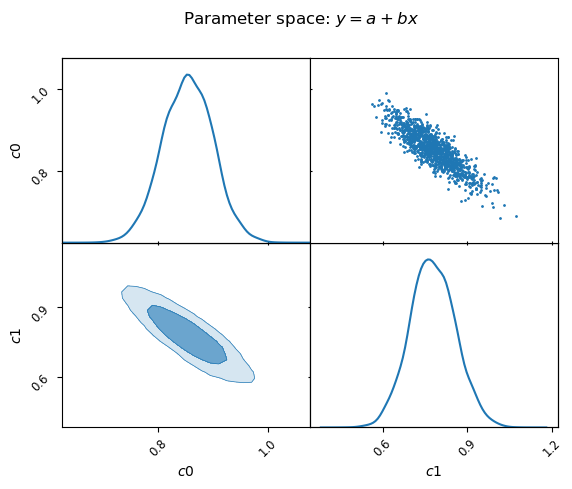

In [7]:
samples_linear.plot_2d(['c0', 'c1'])
plt.suptitle('Parameter space: $y = a + bx$');

Each point in this triangle plot is a set of parameters $(a, b)$.
 The contours show which combinations are consistent with the data.
 Notice the correlation — if the intercept $a$ is higher, the slope $b$
 must be lower to still fit the data.

### 1.7 Data space: the predictive posterior

 But we often care about predictions, not parameters. We can project the
 posterior into **data space** by running each posterior sample through the
 forward model. This is the predictive posterior $P(y|x, D)$.

 `fgivenx` computes this properly: for each $x$, it builds the full
 distribution $P(y|x) = \int P(y|x,\theta) P(\theta|D) d\theta$
 and plots it as filled contours showing 1- and 2-sigma regions.

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

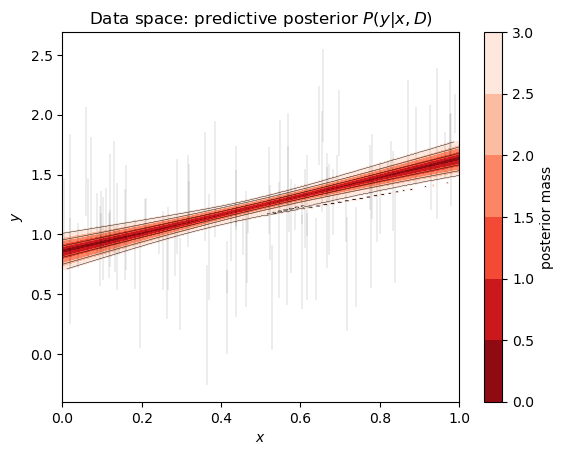

In [8]:
from fgivenx import plot_contours

def linear_model(x_val, theta):
    return theta[0] + theta[1] * x_val

x_plot = np.linspace(0, 1, 200)
theta_samples = samples_linear.sample(500)[['c0', 'c1']].to_numpy()

fig, ax = plt.subplots()
cbar = plot_contours(linear_model, x_plot, theta_samples, ax=ax)
ax.errorbar(x, y, yerr=sigma, fmt='.', color='k', capthick=0.1, markersize=0, linewidth=0.1)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Data space: predictive posterior $P(y|x, D)$')
plt.colorbar(cbar, label='posterior mass');

The colours show the posterior probability mass in data space.
 This is sampling in action: each posterior sample is propagated through the
 forward model, and the envelope shows our uncertainty about the prediction —
 proper error bars on the model, not just the parameters.

### 1.8 Model comparison

 Now the real power: which polynomial order best explains the data?
 The **evidence** $\mathcal{Z}$ answers this automatically.

In [9]:
models = {
    '$a$': [0],
    '$a+bx$': [0, 1],
    '$a+bx^2$': [0, 2],
    '$a+bx^3$': [0, 3],
    '$a+bx+cx^2$': [0, 1, 2],
    '$a+bx+cx^3$': [0, 1, 3],
    '$a+bx+cx^2+dx^3$': [0, 1, 2, 3],
}

results = {}
for label, powers in models.items():
    print(f"\nRunning {label}...")
    results[label] = run_line_fitting(powers)


Running $a$...


NS [0]: 0 dead [00:00, ? dead/s]

NS [0]: 50 dead [00:00, 53.80 dead/s]

NS [0]: 3650 dead [00:00, 3675.58 dead/s]


Running $a+bx$...


...

NS [0, 1, 2, 3]: 2900 dead [00:01, 3630.99 dead/s]

NS [0, 1, 2, 3]: 3950 dead [00:01, 4963.41 dead/s]

NS [0, 1, 2, 3]: 5100 dead [00:01, 6366.38 dead/s]

NS [0, 1, 2, 3]: 6100 dead [00:01, 7228.92 dead/s]

NS [0, 1, 2, 3]: 6650 dead [00:01, 3889.04 dead/s]

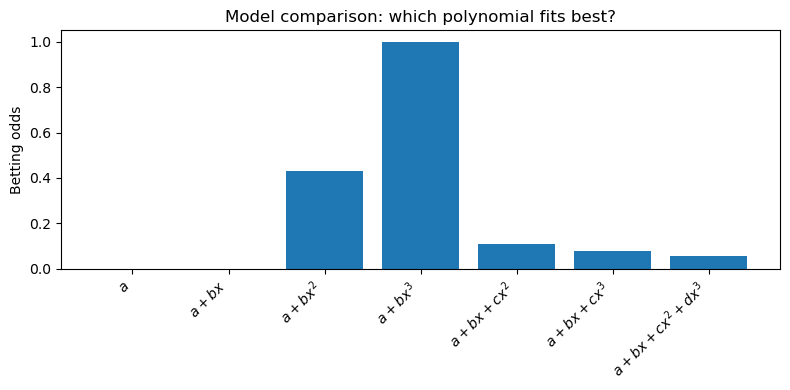

In [10]:
labels = list(results.keys())
logZs = np.array([float(results[l].logZ()) for l in labels])
logZs -= logZs.max()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(labels)), np.exp(logZs - np.max(logZs)))
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Betting odds')
ax.set_title('Model comparison: which polynomial fits best?')
fig.tight_layout();

The evidence automatically penalises overly complex models (Occam's razor).
 The model $a + bx^3$ should win — it matches the true data-generating process.

## Part 2: Satellite Orbit Determination

 Now we apply the same framework to a real inverse problem from GNSS:
 inferring a satellite's orbital elements from noisy position observations.

 The forward model is **jaxsgp4** — a differentiable SGP4 propagator
 written in JAX by Charlotte Priestley.

In [11]:
from jaxsgp4 import tle2sat, sgp4, Satellite

### 2.1 Load observation data

 We have a TLE (Two-Line Element set) identifying a Starlink satellite,
 and 20 noisy position measurements in the TEME frame.

In [12]:
data = np.load("observations.npz", allow_pickle=True)
times = jnp.array(data["times"])
positions_obs = jnp.array(data["positions_obs"])
sigma_obs = float(data["sigma_obs"])
tle_line1 = str(data["tle_line1"])
tle_line2 = str(data["tle_line2"])

print(f"TLE:\n  {tle_line1}\n  {tle_line2}")
print(f"\n{len(times)} observations over {float(times[-1]):.0f} minutes")
print(f"Position noise: {sigma_obs} km per component")

TLE:
  1 44714U 19074B   26013.33334491  .00010762  00000+0  67042-3 0  9990
  2 44714  53.0657  75.1067 0002699  79.3766  82.4805 15.10066292  5798

20 observations over 185 minutes
Position noise: 10.0 km per component


### 2.2 The forward model

 Parse the TLE and propagate. SGP4 takes orbital elements and a time
 offset (minutes from epoch) and returns position and velocity in km.

In [13]:
sat = tle2sat(tle_line1, tle_line2)

In [14]:
# Propagate to all observation times
sgp4_vmap = jax.vmap(sgp4, in_axes=(None, 0))
rvs, errors = sgp4_vmap(sat, times)
positions_model = rvs[:, :3]

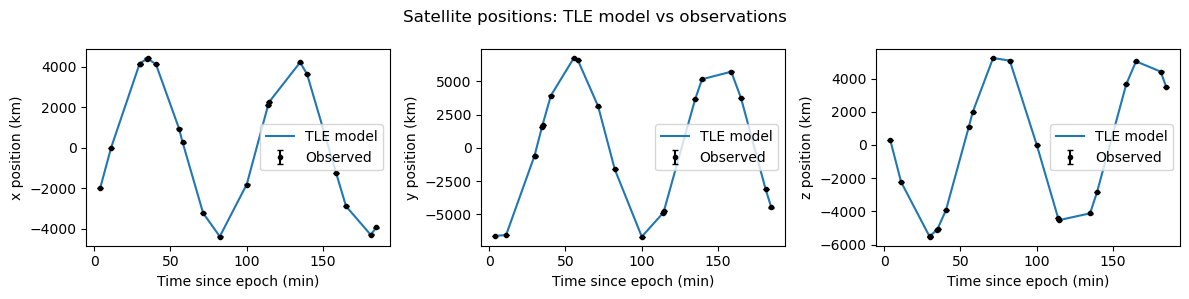

In [15]:
# Plot observed vs model positions
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
labels = ['x', 'y', 'z']
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.errorbar(np.array(times), np.array(positions_obs[:, i]),
                yerr=sigma_obs, fmt='.', color='k', capsize=2, label='Observed')
    ax.plot(np.array(times), np.array(positions_model[:, i]), '-', color='C0', label='TLE model')
    ax.set_xlabel('Time since epoch (min)')
    ax.set_ylabel(f'{label} position (km)')
    ax.legend()
fig.suptitle('Satellite positions: TLE model vs observations')
fig.tight_layout();

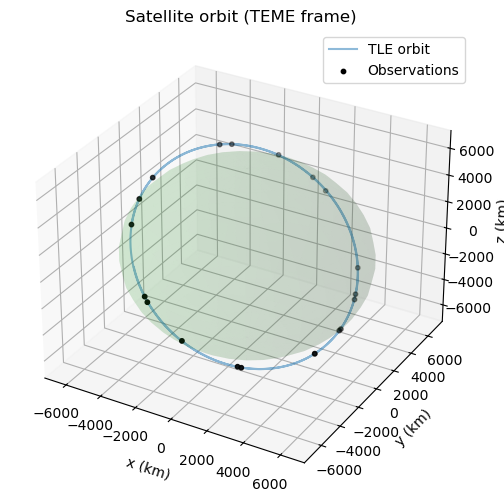

In [16]:
# 3D orbit plot
t_dense = jnp.linspace(0, float(times[-1]), 500)
rvs_dense, _ = jax.vmap(sgp4, in_axes=(None, 0))(sat, t_dense)
pos_dense = np.array(rvs_dense[:, :3])

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(pos_dense[:, 0], pos_dense[:, 1], pos_dense[:, 2], 'C0-', alpha=0.5, label='TLE orbit')
ax.scatter(np.array(positions_obs[:, 0]), np.array(positions_obs[:, 1]),
           np.array(positions_obs[:, 2]), c='k', s=10, label='Observations')
# Earth sphere
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
R_earth = 6378.0
ax.plot_surface(R_earth*np.cos(u)*np.sin(v), R_earth*np.sin(u)*np.sin(v),
                R_earth*np.cos(v), alpha=0.1, color='C2')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_zlabel('z (km)')
ax.legend()
ax.set_title('Satellite orbit (TEME frame)');

### 2.3 Simple inference: two orbital elements

 We start by inferring just two parameters — inclination ($i_0$) and
 right ascension of ascending node ($\Omega_0$) — fixing everything
 else at the TLE values. This gives a fast, clear posterior.

In [17]:
def make_satellite(params, base_sat):
    """Build a Satellite with some elements replaced by inferred values."""
    return Satellite(
        n0=params.get("n0", base_sat.n0),
        e0=params.get("e0", base_sat.e0),
        i0=params.get("i0", base_sat.i0),
        w0=params.get("w0", base_sat.w0),
        Omega0=params.get("Omega0", base_sat.Omega0),
        M0=params.get("M0", base_sat.M0),
        Bstar=params.get("Bstar", base_sat.Bstar),
        epochdays=base_sat.epochdays,
        epochyr=base_sat.epochyr,
    )

In [18]:
# True values (from TLE) and prior widths
true_i0 = float(sat.i0)
true_Omega0 = float(sat.Omega0)

# Prior: uniform, centred on TLE values
prior_width_i0 = 2.0       # degrees
prior_width_Omega0 = 4.0   # degrees

def logprior_2d(params):
    lp = jax.scipy.stats.uniform.logpdf(params["i0"], true_i0 - prior_width_i0/2, prior_width_i0)
    lp += jax.scipy.stats.uniform.logpdf(params["Omega0"], true_Omega0 - prior_width_Omega0/2, prior_width_Omega0)
    return lp

def loglikelihood_2d(params):
    test_sat = make_satellite(params, sat)
    rvs, _ = sgp4_vmap(test_sat, times)
    positions_pred = rvs[:, :3]
    return -0.5 * jnp.sum(((positions_obs - positions_pred) / sigma_obs) ** 2)

In [19]:
# Run nested sampling
num_live = 500
num_dims = 2
algo_2d = blackjax.nss(
    logprior_fn=logprior_2d,
    loglikelihood_fn=loglikelihood_2d,
    num_delete=num_live // 10,
    num_inner_steps=num_dims * 5,
)

rng_key = jax.random.PRNGKey(1)
rng_key, key1, key2 = jax.random.split(rng_key, 3)
particles_2d = {
    "i0": jax.random.uniform(key1, (num_live,),
        minval=true_i0 - prior_width_i0/2, maxval=true_i0 + prior_width_i0/2),
    "Omega0": jax.random.uniform(key2, (num_live,),
        minval=true_Omega0 - prior_width_Omega0/2, maxval=true_Omega0 + prior_width_Omega0/2),
}

live = jax.jit(algo_2d.init)(particles_2d)
step_fn = jax.jit(algo_2d.step)

dead = []
with tqdm.tqdm(desc="NS 2D", unit=" dead") as pbar:
    while not live.integrator.logZ_live - live.integrator.logZ < -3:
        rng_key, subkey = jax.random.split(rng_key)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_live // 10)

dead_2d = blackjax.ns.utils.finalise(live, dead)

samples_2d = NestedSamples(
    dead_2d.particles.position,
    logL=dead_2d.particles.loglikelihood,
    logL_birth=dead_2d.particles.loglikelihood_birth,
    labels={"i0": r"$i_0$ (deg)", "Omega0": r"$\Omega_0$ (deg)"},
)

print(f"log Z = {samples_2d.logZ():.1f}")

NS 2D: 0 dead [00:00, ? dead/s]

NS 2D: 50 dead [00:02, 18.12 dead/s]

NS 2D: 150 dead [00:02, 66.31 dead/s]

NS 2D: 250 dead [00:02, 127.45 dead/s]

NS 2D: 400 dead [00:03, 235.06 dead/s]

...

NS 2D: 4650 dead [00:07, 1003.14 dead/s]

NS 2D: 4800 dead [00:07, 988.08 dead/s] 

NS 2D: 4900 dead [00:07, 979.39 dead/s]

NS 2D: 5000 dead [00:07, 647.20 dead/s]

log Z = -33.7


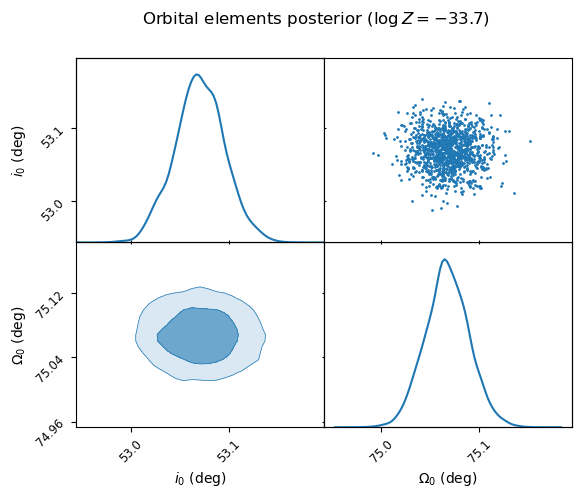

In [20]:
# Corner plot with true values
samples_2d.plot_2d(["i0", "Omega0"])
plt.suptitle(f'Orbital elements posterior ($\\log Z = {float(samples_2d.logZ()):.1f}$)');

#### Posterior predictive: what orbits are consistent with the data?

 Draw 100 posterior samples, propagate each, and overlay the orbits.

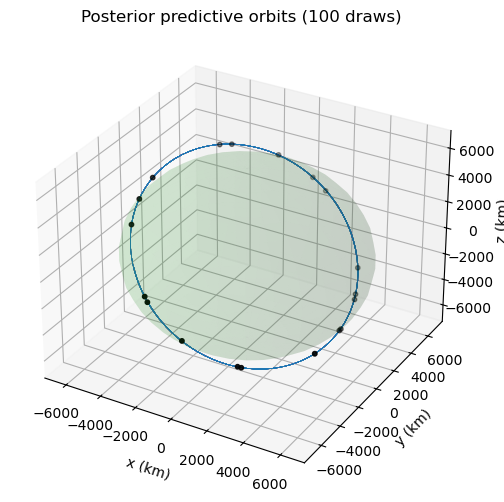

In [21]:
posterior_2d = samples_2d.sample(100)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
for _, row in posterior_2d.iterrows():
    params = {"i0": float(row["i0"]), "Omega0": float(row["Omega0"])}
    test_sat = make_satellite(params, sat)
    rvs_sample, _ = jax.vmap(sgp4, in_axes=(None, 0))(test_sat, t_dense)
    pos = np.array(rvs_sample[:, :3])
    ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], 'C0-', alpha=0.05, linewidth=0.5)

ax.scatter(np.array(positions_obs[:, 0]), np.array(positions_obs[:, 1]),
           np.array(positions_obs[:, 2]), c='k', s=10, zorder=5)
ax.plot_surface(R_earth*np.cos(u)*np.sin(v), R_earth*np.sin(u)*np.sin(v),
                R_earth*np.cos(v), alpha=0.1, color='C2')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_zlabel('z (km)')
ax.set_title('Posterior predictive orbits (100 draws)');

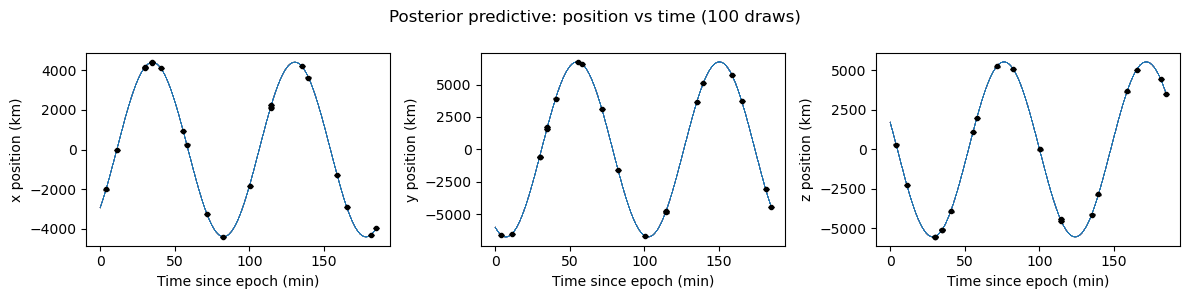

In [22]:
# Same in data space: position components vs time
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for _, row in posterior_2d.iterrows():
    params = {"i0": float(row["i0"]), "Omega0": float(row["Omega0"])}
    test_sat = make_satellite(params, sat)
    rvs_sample, _ = sgp4_vmap(test_sat, t_dense)
    pos = np.array(rvs_sample[:, :3])
    for i, ax in enumerate(axes):
        ax.plot(np.array(t_dense), pos[:, i], 'C0-', alpha=0.05, linewidth=0.5)

for i, (ax, label) in enumerate(zip(axes, ['x', 'y', 'z'])):
    ax.errorbar(np.array(times), np.array(positions_obs[:, i]),
                yerr=sigma_obs, fmt='.', color='k', capsize=2)
    ax.set_xlabel('Time since epoch (min)')
    ax.set_ylabel(f'{label} position (km)')
fig.suptitle('Posterior predictive: position vs time (100 draws)')
fig.tight_layout();

### 2.4 More parameters

 Now let's infer four orbital elements: $i_0$, $\Omega_0$, $e_0$, and $n_0$.

In [23]:
true_e0 = float(sat.e0)
true_n0 = float(sat.n0)

prior_width_e0 = 0.01
prior_width_n0 = 0.1

def logprior_4d(params):
    lp = jax.scipy.stats.uniform.logpdf(params["i0"], true_i0 - prior_width_i0/2, prior_width_i0)
    lp += jax.scipy.stats.uniform.logpdf(params["Omega0"], true_Omega0 - prior_width_Omega0/2, prior_width_Omega0)
    lp += jax.scipy.stats.uniform.logpdf(params["e0"], true_e0 - prior_width_e0/2, prior_width_e0)
    lp += jax.scipy.stats.uniform.logpdf(params["n0"], true_n0 - prior_width_n0/2, prior_width_n0)
    return lp

def loglikelihood_4d(params):
    test_sat = make_satellite(params, sat)
    rvs, _ = sgp4_vmap(test_sat, times)
    positions_pred = rvs[:, :3]
    return -0.5 * jnp.sum(((positions_obs - positions_pred) / sigma_obs) ** 2)

In [24]:
num_dims = 4
algo_4d = blackjax.nss(
    logprior_fn=logprior_4d,
    loglikelihood_fn=loglikelihood_4d,
    num_delete=num_live // 10,
    num_inner_steps=num_dims * 5,
)

rng_key, *keys = jax.random.split(rng_key, 5)
particles_4d = {
    "i0": jax.random.uniform(keys[0], (num_live,),
        minval=true_i0 - prior_width_i0/2, maxval=true_i0 + prior_width_i0/2),
    "Omega0": jax.random.uniform(keys[1], (num_live,),
        minval=true_Omega0 - prior_width_Omega0/2, maxval=true_Omega0 + prior_width_Omega0/2),
    "e0": jax.random.uniform(keys[2], (num_live,),
        minval=true_e0 - prior_width_e0/2, maxval=true_e0 + prior_width_e0/2),
    "n0": jax.random.uniform(keys[3], (num_live,),
        minval=true_n0 - prior_width_n0/2, maxval=true_n0 + prior_width_n0/2),
}

live = jax.jit(algo_4d.init)(particles_4d)
step_fn = jax.jit(algo_4d.step)

dead = []
with tqdm.tqdm(desc="NS 4D", unit=" dead") as pbar:
    while not live.integrator.logZ_live - live.integrator.logZ < -3:
        rng_key, subkey = jax.random.split(rng_key)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_live // 10)

dead_4d = blackjax.ns.utils.finalise(live, dead)

samples_4d = NestedSamples(
    dead_4d.particles.position,
    logL=dead_4d.particles.loglikelihood,
    logL_birth=dead_4d.particles.loglikelihood_birth,
    labels={"i0": r"$i_0$", "Omega0": r"$\Omega_0$", "e0": r"$e_0$", "n0": r"$n_0$"},
)

print(f"log Z = {samples_4d.logZ():.1f}")

NS 4D: 0 dead [00:00, ? dead/s]

NS 4D: 50 dead [00:02, 18.05 dead/s]

NS 4D: 100 dead [00:02, 41.43 dead/s]

NS 4D: 150 dead [00:02, 71.26 dead/s]

NS 4D: 200 dead [00:03, 107.10 dead/s]

...

NS 4D: 7650 dead [00:18, 513.81 dead/s]

NS 4D: 7750 dead [00:18, 514.81 dead/s]

NS 4D: 7850 dead [00:18, 515.09 dead/s]

NS 4D: 7850 dead [00:18, 418.23 dead/s]

log Z = -39.6


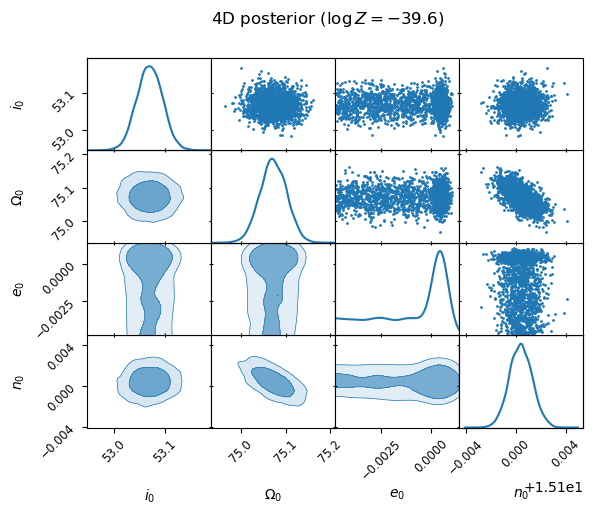

In [25]:
samples_4d.plot_2d(["i0", "Omega0", "e0", "n0"])
plt.suptitle(f'4D posterior ($\\log Z = {float(samples_4d.logZ()):.1f}$)');

Notice the degeneracies — some parameters are correlated. This is
 the same physics as the "banana" in the LIGO mass plot from the talk.

### 2.5 Model comparison: detecting eccentricity

 Is the orbit circular or elliptical? We can answer this with Bayesian
 model comparison. Fit two models:

 - **Circular**: fix $e_0 = 0$, infer $i_0$, $\Omega_0$, $n_0$
 - **Elliptical**: infer $e_0$ as well

 The evidence ratio tells us which model the data prefer.

In [26]:
def logprior_circular(params):
    lp = jax.scipy.stats.uniform.logpdf(params["i0"], true_i0 - prior_width_i0/2, prior_width_i0)
    lp += jax.scipy.stats.uniform.logpdf(params["Omega0"], true_Omega0 - prior_width_Omega0/2, prior_width_Omega0)
    lp += jax.scipy.stats.uniform.logpdf(params["n0"], true_n0 - prior_width_n0/2, prior_width_n0)
    return lp

def loglikelihood_circular(params):
    # Force e0 = 0
    params_fixed = {**params, "e0": 0.0}
    test_sat = make_satellite(params_fixed, sat)
    rvs, _ = sgp4_vmap(test_sat, times)
    positions_pred = rvs[:, :3]
    return -0.5 * jnp.sum(((positions_obs - positions_pred) / sigma_obs) ** 2)

In [27]:
num_dims_circ = 3
algo_circ = blackjax.nss(
    logprior_fn=logprior_circular,
    loglikelihood_fn=loglikelihood_circular,
    num_delete=num_live // 10,
    num_inner_steps=num_dims_circ * 5,
)

rng_key, *keys = jax.random.split(rng_key, 4)
particles_circ = {
    "i0": jax.random.uniform(keys[0], (num_live,),
        minval=true_i0 - prior_width_i0/2, maxval=true_i0 + prior_width_i0/2),
    "Omega0": jax.random.uniform(keys[1], (num_live,),
        minval=true_Omega0 - prior_width_Omega0/2, maxval=true_Omega0 + prior_width_Omega0/2),
    "n0": jax.random.uniform(keys[2], (num_live,),
        minval=true_n0 - prior_width_n0/2, maxval=true_n0 + prior_width_n0/2),
}

live = jax.jit(algo_circ.init)(particles_circ)
step_fn = jax.jit(algo_circ.step)

dead = []
with tqdm.tqdm(desc="NS circular", unit=" dead") as pbar:
    while not live.integrator.logZ_live - live.integrator.logZ < -3:
        rng_key, subkey = jax.random.split(rng_key)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_live // 10)

dead_circ = blackjax.ns.utils.finalise(live, dead)
samples_circ = NestedSamples(
    dead_circ.particles.position,
    logL=dead_circ.particles.loglikelihood,
    logL_birth=dead_circ.particles.loglikelihood_birth,
)

logZ_circ = float(samples_circ.logZ())
logZ_ellip = float(samples_4d.logZ())
log_bayes_factor = logZ_ellip - logZ_circ

print(f"log Z (circular):   {logZ_circ:.1f}")
print(f"log Z (elliptical): {logZ_ellip:.1f}")
print(f"log Bayes factor:   {log_bayes_factor:.1f}")

if log_bayes_factor > 1:
    print("Data prefer the elliptical model (evidence for eccentricity)")
elif log_bayes_factor < -1:
    print("Data prefer the circular model (Occam's razor penalises unnecessary eccentricity)")
else:
    print("Inconclusive — models are comparably supported")

NS circular: 0 dead [00:00, ? dead/s]

NS circular: 50 dead [00:02, 20.02 dead/s]

NS circular: 150 dead [00:02, 71.31 dead/s]

NS circular: 250 dead [00:02, 132.53 dead/s]

NS circular: 350 dead [00:02, 203.75 dead/s]

...

NS circular: 6850 dead [00:11, 754.70 dead/s]

NS circular: 6950 dead [00:11, 755.98 dead/s]

NS circular: 7050 dead [00:11, 753.29 dead/s]

NS circular: 7050 dead [00:11, 594.82 dead/s]

log Z (circular):   -40.0
log Z (elliptical): -39.6
log Bayes factor:   0.4
Inconclusive — models are comparably supported


For this satellite ($e_0 \approx 0.0003$), the orbit is nearly circular.
 With 10 km noise, the eccentricity is likely undetectable — the circular
 model should win via Occam's razor, just as the simpler polynomial won
 in Part 1.

## Part 3: Extensions

 The structure is always the same:
 1. Write a forward model $y = f(x; \theta)$ in JAX
 2. Define `logprior_fn(params)` and `loglikelihood_fn(params)`
 3. Draw initial `particles` from the prior
 4. Run `blackjax.nss()` and visualise with `anesthetic`

 Here are some directions relevant to GNSS-R:

 ### Orbit determination
 - **Noise sensitivity**: at what noise level can you detect the eccentricity?
   Try $\sigma = 1$ km, $0.1$ km. How does the Bayes factor change?
 - **More parameters**: add $w_0$ (argument of perigee) or $M_0$ (mean anomaly).
   What degeneracies appear in the corner plot?
 - **Constellation fitting**: observe multiple satellites simultaneously.
   `jaxsgp4.tle2sat_array` parses multiple TLEs, and `jax.vmap` vectorises
   over satellites. Can you fit orbital planes for a Starlink shell?

 ### GNSS-R surface inference
 - **Soil moisture from reflected signals**: write a forward model for the
   reflection coefficient as a function of soil dielectric constant and roughness.
   The likelihood compares predicted vs observed signal-to-noise ratio.
   Use nested sampling to infer soil parameters and compare models
   (e.g. smooth vs rough surface).
 - **Sea surface roughness**: the delay-Doppler map depends on wind speed
   and significant wave height. Define a simplified DDM forward model,
   add noise, and infer ocean surface parameters.

 ### Ground-penetrating radar
 - **Layer detection**: a forward model for travel time through $N$ layers
   with unknown thicknesses and permittivities. Use model comparison
   (evidence) to determine the number of subsurface layers -- this is
   exactly the polynomial order selection problem from Part 1.

 ### General recipe
 - If your forward model is in Python/NumPy, porting to JAX is often
   just replacing `import numpy as np` with `import jax.numpy as jnp`.
 - If it's in Fortran/C++, an LLM can help translate it.
 - The bottleneck is usually getting the forward model right, not the
   inference machinery.